In [8]:
!pip show xgboost


Name: xgboost
Version: 1.7.6
Summary: XGBoost Python Package
Home-page: https://github.com/dmlc/xgboost
Author: 
Author-email: 
License: Apache-2.0
Location: C:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: numpy, scipy
Required-by: 


In [1]:
# [code]
# 1. Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from supabase import create_client, Client
from dotenv import load_dotenv
import os
from datetime import datetime, timedelta

# Muat variabel lingkungan dari file .env
load_dotenv()

# --- Konfigurasi Supabase ---
# Ganti dengan nama tabel dan kolom timestamp Anda di Supabase
TABLE_NAME = "tb_konsentrasi_gas" 
TIMESTAMP_COLUMN = "created_at" 

# Ambil URL dan Key dari environment variables
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError("Pastikan SUPABASE_URL dan SUPABASE_KEY sudah diatur di file .env")

# Inisialisasi klien Supabase
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Library berhasil diimpor dan klien Supabase diinisialisasi.")

Library berhasil diimpor dan klien Supabase diinisialisasi.


In [2]:
# [code]
# 2. Mengambil Data Per Menit dengan Pagination (METODE PALING AMPUH - VERSI MULTI-FITUR)

# Ambil data untuk 7 hari terakhir
seven_days_ago = datetime.now() - timedelta(days=3)
print(f"Langkah 2: Mengambil data per menit dari {seven_days_ago.strftime('%Y-%m-%d %H:%M')}...")

# --- KODE PAGINATION ---
# Kita akan mengambil data dalam potongan (chunks) berukuran 1000
all_data = []
page_size = 1000
offset = 0

# --- PERUBAHAN DI SINI ---
# Ganti nama kolom sesuai dengan yang ada di database Anda
COL_PM25 = "pm25_ugm3"
COL_CO = "co_corrected_ugm3"
COL_SUHU = "temperature"
COL_KELEMBAPAN = "humidity"
COL_TIMESTAMP = "created_at"

while True:
    print(f"Mengambil {page_size} data dimulai dari baris ke-{offset}...")
    
    # Lakukan query dengan offset untuk mendapatkan "halaman" berikutnya
    # Pilih semua kolom yang diperlukan
    response = supabase.table(TABLE_NAME) \
        .select(f"{COL_PM25}, {COL_CO}, {COL_SUHU}, {COL_KELEMBAPAN}, {COL_TIMESTAMP}") \
        .gte(COL_TIMESTAMP, seven_days_ago.isoformat()) \
        .order(COL_TIMESTAMP, desc=False) \
        .range(offset, offset + page_size - 1) \
        .execute()
    
    current_data = response.data
    if not current_data:
        print("Semua data telah diambil.")
        break
        
    all_data.extend(current_data)
    offset += len(current_data)

# Konversi semua data yang telah dikumpulkan ke DataFrame Pandas
df_raw = pd.DataFrame(all_data)

# --- Validasi dan Pembersihan Data KRUSIAL ---
if df_raw.empty:
    print("ERROR: Tidak ada data yang ditemukan.")
else:
    print(f"\nData mentah berhasil diambil. Total baris: {len(df_raw)}")
    print("Info Tipe Data Awal:")
    df_raw.info()

    # --- PERUBAHAN DI SINI: Konversi semua kolom numerik ---
    # Konversi kolom-kolom ke numerik. errors='coerce' akan mengubah nilai tidak valid menjadi NaN.
    for col in [COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN]:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    
    # Konversi kolom timestamp ke datetime
    df_raw[COL_TIMESTAMP] = pd.to_datetime(df_raw[COL_TIMESTAMP])

    # Hapus baris yang memiliki nilai kosong (NaN) di kolom penting
    initial_count = len(df_raw)
    df_raw.dropna(subset=[COL_PM25, COL_CO, COL_SUHU, COL_KELEMBAPAN], inplace=True)
    final_count = len(df_raw)
    print(f"\n{initial_count - final_count} baris dengan nilai tidak valid telah dihapus.")

    # Jadikan timestamp sebagai index, hapus duplikat, dan urutkan
    df_clean = df_raw.set_index(COL_TIMESTAMP)
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    df_clean.sort_index(inplace=True)
    
    # Ganti nama kolom untuk kemudahan
    df_clean.rename(columns={
        COL_PM25: 'pm2.5',
        COL_CO: 'co',
        COL_SUHU: 'suhu',
        COL_KELEMBAPAN: 'kelembapan'
    }, inplace=True)

    print("\nData setelah pembersihan dan konversi tipe data:")
    df_clean.info()
    print("\n5 baris pertama data bersih:")
    print(df_clean.head())

Langkah 2: Mengambil data per menit dari 2025-12-09 00:37...
Mengambil 1000 data dimulai dari baris ke-0...
Mengambil 1000 data dimulai dari baris ke-1000...
Mengambil 1000 data dimulai dari baris ke-2000...
Mengambil 1000 data dimulai dari baris ke-3000...
Mengambil 1000 data dimulai dari baris ke-3833...
Semua data telah diambil.

Data mentah berhasil diambil. Total baris: 3833
Info Tipe Data Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pm25_ugm3          3833 non-null   float64
 1   co_corrected_ugm3  3833 non-null   float64
 2   temperature        3833 non-null   float64
 3   humidity           3833 non-null   float64
 4   created_at         3833 non-null   object 
dtypes: float64(4), object(1)
memory usage: 149.9+ KB

0 baris dengan nilai tidak valid telah dihapus.

Data setelah pembersihan dan konversi tipe data:
<

In [3]:
# [code]
# 3. Agregasi Data Menjadi Per Jam dan Rekayasa Fitur (VERSI MULTI-FITUR)

if 'df_clean' in locals() and not df_clean.empty:
    print("Langkah 3: Mengelompokkan data per menit menjadi rata-rata per jam...")
    
    # --- PERUBAHAN DI SINI: Resample semua kolom numerik sekaligus ---
    df_hourly = df_clean.resample('h').mean()
    df_hourly.dropna(inplace=True)
    
    print(f"Jumlah titik data per jam: {len(df_hourly)}")
    
    # --- REKAYASA FITUR (FEATURE ENGINEERING) ---
    features_df = df_hourly.copy() # Mulai dengan data yang sudah diresample

    # Daftar kolom yang akan dibuatkan fitur lag dan rolling
    feature_cols = ['pm2.5', 'co', 'suhu', 'kelembapan']
    
    # --- PERUBAHAN DI SINI: Buat fitur untuk setiap kolom ---
    for col in feature_cols:
        # Fitur Lag
        features_df[f'{col}_lag_1h'] = features_df[col].shift(1)
        features_df[f'{col}_lag_24h'] = features_df[col].shift(24)
        
        # Fitur Rolling
        features_df[f'{col}_rolling_mean_3h'] = features_df[col].rolling(window=3).mean()
        features_df[f'{col}_rolling_std_3h'] = features_df[col].rolling(window=3).std()

    # Fitur Berbasis Waktu (tidak berubah)
    features_df['hour'] = features_df.index.hour
    features_df['dayofweek'] = features_df.index.dayofweek

    # Hapus baris dengan nilai NaN
    features_df.dropna(inplace=True)

    print(f"\nJumlah baris akhir setelah pembuatan fitur: {len(features_df)}")
    print(f"Jumlah total fitur: {len(features_df.columns)}")
    
    if features_df.empty:
        print("ERROR: DataFrame fitur kosong.")
    else:
        print("\n5 baris pertama dari DataFrame fitur:")
        print(features_df.head())
else:
    print("Langkah 3 dilewati.")

Langkah 3: Mengelompokkan data per menit menjadi rata-rata per jam...
Jumlah titik data per jam: 66

Jumlah baris akhir setelah pembuatan fitur: 42
Jumlah total fitur: 22

5 baris pertama dari DataFrame fitur:
                              pm2.5         co       suhu  kelembapan  \
created_at                                                              
2025-12-10 00:00:00+00:00  3.298000  58.426458  33.165000   63.441667   
2025-12-10 01:00:00+00:00  3.403390  59.879030  34.238983   60.013559   
2025-12-10 02:00:00+00:00  3.859333  60.841904  34.790000   58.565000   
2025-12-10 03:00:00+00:00  4.723390  60.711565  34.945763   59.222034   
2025-12-10 04:00:00+00:00  4.377458  62.193177  35.372881   55.342373   

                           pm2.5_lag_1h  pm2.5_lag_24h  pm2.5_rolling_mean_3h  \
created_at                                                                      
2025-12-10 00:00:00+00:00      3.089322       3.121364               3.685661   
2025-12-10 01:00:00+00:00      3.29

In [4]:
# [code]
# 4. Persiapan Data untuk Model

# Pastikan features_df tidak kosong
if 'features_df' in locals() and not features_df.empty:
    print("Langkah 4: Mempersiapkan data untuk model...")

    # Tentukan Target (y) dan Fitur (X)
    # Target adalah pm2.5 di jam berikutnya, jadi kita geser kolom 'pm2.5' ke atas
    features_df['target'] = features_df['pm2.5'].shift(-1)
    features_df.dropna(inplace=True) # Hapus baris terakhir yang tidak punya target

    # Pisahkan fitur (X) dan target (y)
    X = features_df.drop('target', axis=1)
    y = features_df['target']

    # Pembagian data latih dan uji (Time Series Split)
    # Kita tidak boleh membagi secara acak. Data latih harus dari waktu yang lebih lama.
    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"Ukuran data latih (X_train): {X_train.shape}")
    print(f"Ukuran data uji (X_test): {X_test.shape}")
else:
    print("Langkah 4 dilewati.")

Langkah 4: Mempersiapkan data untuk model...
Ukuran data latih (X_train): (32, 22)
Ukuran data uji (X_test): (9, 22)


In [69]:
# [code]
# 5. Pelatihan Model (XGBoost)

if 'X_train' in locals():
    print("Langkah 5: Melatih model XGBoost...")
    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        objective='reg:squarederror',
        early_stopping_rounds=50, # Mencegah overfitting
        n_jobs=-1 # Gunakan semua CPU core
    )

    model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              verbose=False) # Matikan log agar output bersih
    
    print("Model XGBoost berhasil dilatih.")
else:
    print("Langkah 5 dilewati.")

Langkah 5: Melatih model XGBoost...
Model XGBoost berhasil dilatih.


Langkah 6: Mengevaluasi performa model...

--- Hasil Evaluasi Model pada Data Uji ---
Mean Absolute Error (MAE): 0.59 µg/m³
Root Mean Squared Error (RMSE): 0.70 µg/m³
Mean Absolute Percentage Error (MAPE): 14.26%
R-squared (R²): -0.16
------------------------------------------


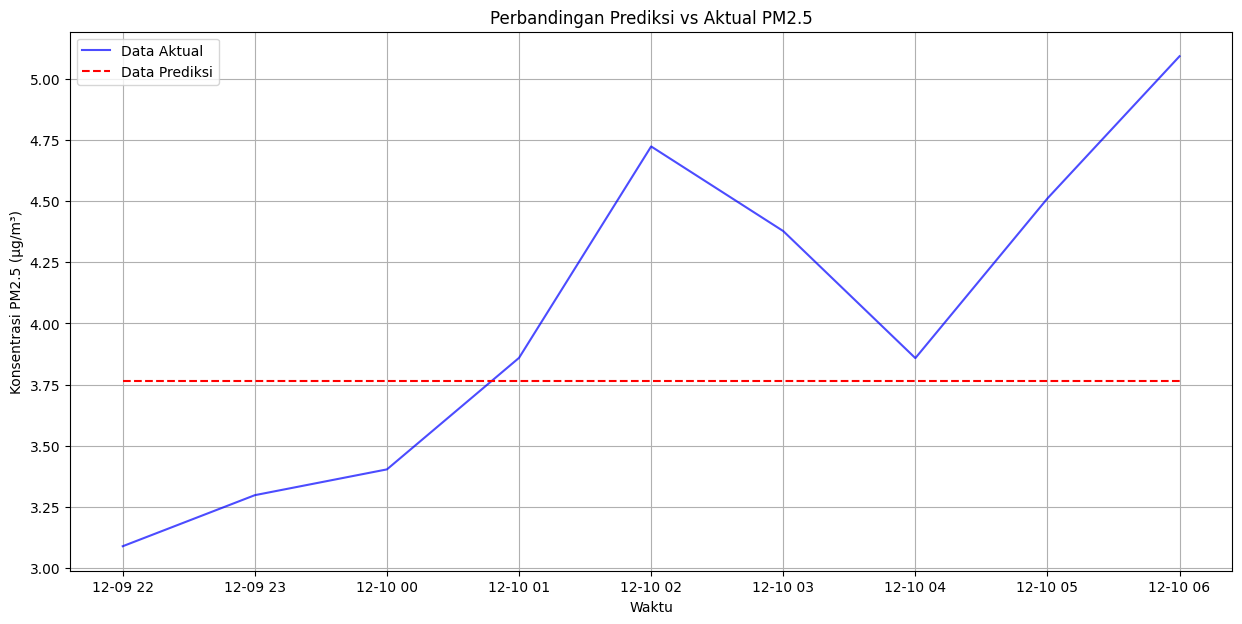

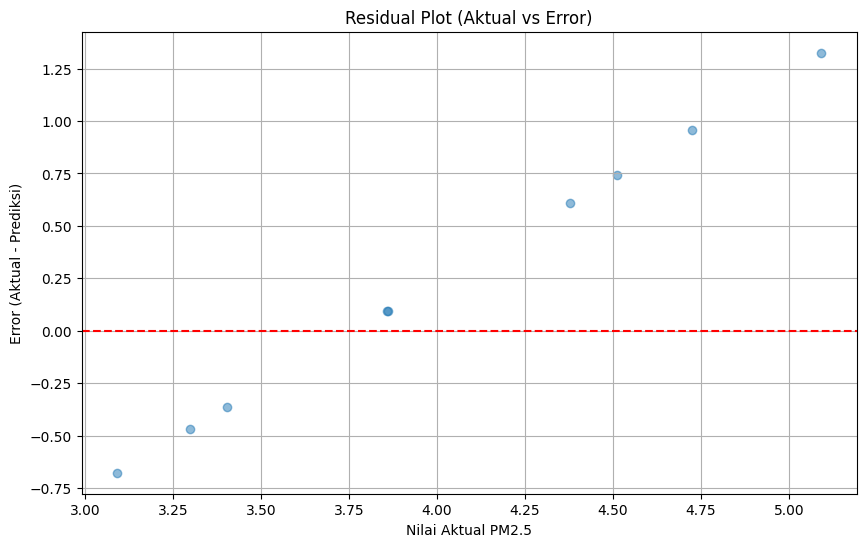

In [7]:
# [code]
# 6. Evaluasi Model yang Lebih Lengkap (Termasuk R-squared)

# Impor metrik tambahan dari scikit-learn
from sklearn.metrics import mean_squared_error, r2_score

# Fungsi untuk menghitung MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

if 'model' in locals():
    print("Langkah 6: Mengevaluasi performa model...")
    
    # Buat prediksi pada data uji
    y_pred = model.predict(X_test)

    # --- Hitung Semua Metrik Evaluasi ---
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred) # <-- Perhitungan R-squared

    # --- Tampilkan Hasil Evaluasi ---
    print("\n--- Hasil Evaluasi Model pada Data Uji ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f} µg/m³")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} µg/m³")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R-squared (R²): {r2:.2f}") # <-- Tampilkan R-squared
    print("------------------------------------------")

    # --- Visualisasi 1: Perbandingan Prediksi vs Aktual ---
    plt.figure(figsize=(15, 7))
    plt.plot(y_test.index, y_test, label='Data Aktual', color='blue', alpha=0.7)
    plt.plot(y_test.index, y_pred, label='Data Prediksi', color='red', linestyle='--')
    plt.title('Perbandingan Prediksi vs Aktual PM2.5')
    plt.xlabel('Waktu')
    plt.ylabel('Konsentrasi PM2.5 (µg/m³)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Visualisasi 2: Residual Plot (Plot Error) ---
    # Residual = Nilai Aktual - Nilai Prediksi
    residuals = y_test - y_pred

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residual Plot (Aktual vs Error)')
    plt.xlabel('Nilai Aktual PM2.5')
    plt.ylabel('Error (Aktual - Prediksi)')
    plt.grid(True)
    plt.show()

else:
    print("Langkah 6 dilewati.")

In [51]:
# [code]
# 7. Prediksi untuk 1 Jam ke Depan

if 'model' in locals():
    print("Langkah 7: Membuat prediksi untuk 1 jam ke depan...")
    
    # Ambil baris terakhir dari fitur yang sudah dibuat
    last_features = X.iloc[-1].values.reshape(1, -1)
    
    # Buat prediksi
    next_hour_prediction = model.predict(last_features)
    
    # Tampilkan hasil
    last_timestamp = X.index[-1]
    next_hour_timestamp = last_timestamp + pd.Timedelta(hours=1)
    
    print("-" * 50)
    print(f"Data terakhir yang diketahui: {last_timestamp.strftime('%Y-%m-%d %H:%M')}")
    print(f"Nilai PM2.5 terakhir: {X.iloc[-1]['pm2.5']:.2f} µg/m³")
    print("-" * 50)
    print(f"Prediksi PM2.5 untuk jam berikutnya ({next_hour_timestamp.strftime('%Y-%m-%d %H:%M')}):")
    print(f"-> {next_hour_prediction[0]:.2f} µg/m³")
    print("-" * 50)
else:
    print("Langkah 7 dilewati.")

Langkah 7: Membuat prediksi untuk 1 jam ke depan...
--------------------------------------------------
Data terakhir yang diketahui: 2025-12-10 05:00
Nilai PM2.5 terakhir: 3.86 µg/m³
--------------------------------------------------
Prediksi PM2.5 untuk jam berikutnya (2025-12-10 06:00):
-> 4.02 µg/m³
--------------------------------------------------


In [52]:
!pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.5 MB 991.0 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 2.4 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.5 MB 3.7 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.5 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.5 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.5 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.5 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.5 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 0


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# [code]
# 5. Pelatihan Model (LightGBM)

# Impor library LightGBM
import lightgbm as lgb

if 'X_train' in locals():
    print("Langkah 5: Melatih model LightGBM...")
    
    # Inisialisasi model LightGBM
    # Parameternya mirip dengan XGBoost
    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        objective='regression', # Objective untuk regresi
        metric='mae', # Metrik untuk evaluasi selama pelatihan
        num_leaves=31, # Parameter khas LightGBM
        n_jobs=-1,
        random_state=42
    )

    # Latih model dengan data latih
    # LightGBM juga memiliki fitur early stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(50)] # Cara early stopping di LightGBM
    )
    
    print("Model LightGBM berhasil dilatih.")
else:
    print("Langkah 5 dilewati.")

Langkah 5: Melatih model LightGBM...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 32, number of used features: 0
[LightGBM] [Info] Start training from score 3.958032
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requ